期末作业
美国货币政策不确定性与美国股票市场收益率
数据选择1985-01：2023-01
一、 美国股票市场收益率描述性统计、检验及画图
二、美国货币政策不确定性指数的描述性统计、画图
三、美国货币政策不确定性与美国股票市场收益率的回归

最终成功得到结果，回归显著，得出结论：美国货币政策不确定性可以预测美国股票市场收益率
滞后一期结果仍较显著，但不及当期p值优，因此，得出结论：由于货币政策的时效性，预测美国股票市场收益时，应尽可能选择同期数据。

In [88]:
import numpy as np # 数据处理最重要的模块
import pandas as pd # 数据处理最重要的模块
import scipy.stats as stats # 统计模块
import scipy
# import pymysql  # 导入数据库模块

from datetime import datetime # 时间模块
import statsmodels.formula.api as smf  # OLS regression

# import pyreadr # read RDS file

from matplotlib import style
import matplotlib.pyplot as plt  # 画图模块
import matplotlib.dates as mdates

from matplotlib.font_manager import FontProperties # 作图中文
from pylab import mpl
#mpl.rcParams['font.sans-serif'] = ['SimHei']
#plt.rcParams['font.family'] = 'Times New Roman'

from pandas.tseries.offsets import MonthEnd

#输出矢量图 渲染矢量图
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

from IPython.core.interactiveshell import InteractiveShell # jupyter运行输出的模块
#显示每一个运行结果
InteractiveShell.ast_node_interactivity = 'all'

#设置行不限制数量
#pd.set_option('display.max_rows',None)

#设置列不限制数量
pd.set_option('display.max_columns', None)

In [89]:
US_market_ret = pd.read_csv("C:\\Users\\lenovo\\Desktop\\US stock market return.csv")
US_market_ret['month'] = pd.to_datetime(US_market_ret['month'],format='%Y-%m-%d')
US_market_ret.set_index('month',inplace=True)
US_market_ret.sort_index(inplace=True)
US_market_ret

,r
month,
1926-01-01,0.000561
1926-02-01,-0.033046
1926-03-01,-0.064002
1926-04-01,0.037029
1926-05-01,0.012095
...,...
2023-08-01,-0.020300
2023-09-01,-0.048003
2023-10-01,-0.029225


In [90]:
US_market_new = US_market_ret['1985-01':'2023-01'].copy()
US_market_new['r'] = pd.to_numeric(US_market_new['r'])
US_market_new['Raw_return'] = US_market_new['r'] / US_market_new['r'] - 1

In [91]:
Quarter_US_market = US_market_ret.resample('QE')['r'].apply(lambda x: np.prod(1+x)-1).to_frame()
Quarter_US_market

,r
month,
1926-03-31,-0.094425
1926-06-30,0.105896
1926-09-30,0.067098
1926-12-31,0.027904
1927-03-31,0.051832
...,...
2022-12-31,0.067550
2023-03-31,0.072505
2023-06-30,0.079416


In [92]:
Year_US_market= US_market_ret.resample('YE')['r'].apply(lambda x: np.prod(1+x)-1).to_frame()
Year_US_market

,r
month,
1926-12-31,0.098488
1927-12-31,0.328719
1928-12-31,0.391395
1929-12-31,-0.150955
1930-12-31,-0.289004
...,...
2019-12-31,0.297470
2020-12-31,0.213742
2021-12-31,0.235722


均值mean

In [94]:
np.mean(US_market_ret['1985-01':'2023-01']['r'])

0.009619461706783369

In [95]:
print('美国股票市场年度平均收益率为',Year_US_market['1985':'2023']['r'].mean().round(5)*100,'%',sep="")

美国股票市场年度平均收益率为12.446%


In [96]:
sum(US_market_ret['1985-01':'2023-01']['r']) / len(US_market_ret['2000-01':'2024-09']['r'])

0.015264215277777783

In [97]:
US_market_ret['1985-01':'2023-01']['r'].describe()

count    457.000000
mean       0.009619
std        0.045423
min       -0.225361
25%       -0.016598
50%        0.014521
75%        0.038750
max        0.132193
Name: r, dtype: float64

分位数

In [98]:
len(US_market_ret['1985-01':'2023-01'])

457

In [99]:
len(US_market_ret[US_market_ret["r"] > 0])

738

In [104]:
Quarter_US_market['1985-01':'2023-01']['r'].describe()

count    152.000000
mean       0.029291
std        0.086352
min       -0.238360
25%       -0.005740
50%        0.039661
75%        0.079679
max        0.224507
Name: r, dtype: float64

描述性统计

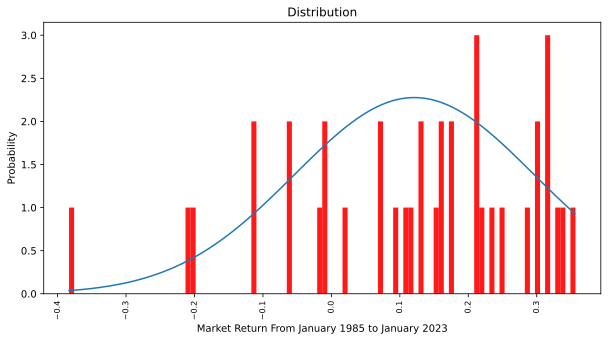

In [105]:
retmean = Year_US_market['1985-01':'2023-01']['r'].mean()
retstd = Year_US_market['1985-01':'2023-01']['r'].std()
retmin = Year_US_market['1985-01':'2023-01']['r'].min()
retmax = Year_US_market['1985-01':'2023-01']['r'].max()


def normfun(x, mu, sigma):
    pdf = np.exp(-((x - mu)**2) /
                 (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    return pdf


x = np.arange(retmin, retmax, 0.001)
y = normfun(x, retmean, retstd)
fig = plt.figure(figsize=(10, 5)) # 图片大小 10，5
plt.plot(x, y)

fig = plt.hist(Year_US_market['1985-01':'2023-01']['r'],
               bins=100,
               histtype='bar',
               color='r',
               alpha=0.9)
plt.xticks(rotation=90, fontsize=8)
plt.title('Distribution')
plt.xlabel('Market Return From January 1985 to January 2023')
plt.ylabel('Probability')
plt.show();


In [106]:
from statsmodels.tsa.stattools import adfuller as ADF
print('原始序列的ADF检验结果为:', ADF(Year_US_market['1985-01':'2023-01']['r']))

原始序列的ADF检验结果为: (-4.30686536080295, 0.00043220809573363175, 4, 33, {'1%': -3.6461350877925254, '5%': -2.954126991123355, '10%': -2.6159676124885216}, -11.366661623781283)


参数检验

In [107]:
Year_US_market['1985-01':'2023-01']['r'].mean()

0.12112695886938815

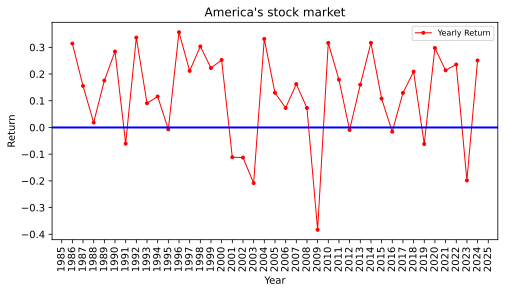

In [108]:
fig, ax = plt.subplots(figsize = (8,4))

ax.plot('r', # 图片数据
'.-', # 图片类型,
color = 'r', # 图片颜色
label = 'Yearly Return', # 图片标签
linewidth = 1, # 图片线宽
data = Year_US_market['1985-01':]) # 图片数据来源
ax.set_title("America's stock market") # 图片标题
ax.set_ylabel('Return') # 图片y轴标签
ax.set_xlabel('Year') # 图片x轴标签

# 添加一条y=0的参考线
plt.axhline(y=0, color='blue', linewidth=2)
# plt.axhline(y=0.005546421267857977, color='green', linewidth=2)

# 设置x轴的日期显示格式
data_format = mdates.DateFormatter('%Y')
ax.xaxis.set_major_formatter(data_format)
ax.xaxis.set_major_locator(mdates.YearLocator())

# 转置x轴的日期显示格式
plt.xticks(rotation = 90)

# 添加图例
plt.legend(loc='upper right',fontsize = 8)
plt.show();

In [109]:
Year_US_market['1985-01':'2023-01']['r'].mean()

0.12112695886938815

In [110]:
stats.ttest_1samp(Year_US_market['1985-01':'2023-01']['r'],0)

TtestResult(statistic=4.261072566987396, pvalue=0.00013425996405157066, df=37)

美国股票收益率图表

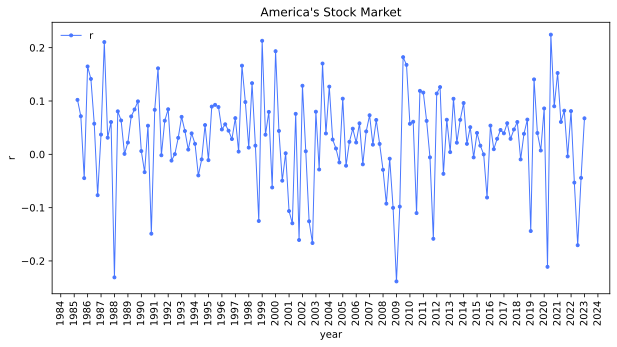

In [112]:
# 画图
fig, ax = plt.subplots(figsize=(10, 5)) # 图片比例
ax.plot(
    'r',  # 要画图的变量名
    '.-',  # 线的类型
    color = '#4876FF',  # 线的颜色 RGB
    label = 'r',  # 这个是线的类别，主要是在多条线画图的时候，起到区别的作用，单条线这个没有影响
    linewidth = 1,  # 线的粗细
    data = Quarter_US_market['1985-01':'2023-01'])  # 画图的数据
ax.set_title("America's Stock Market") # 画图的标题
ax.set_xlabel('year') # 画图的x轴名称
plt.ylabel('r') # 画图的y轴名称

# 设置x轴的日期格式
date_format = mdates.DateFormatter('%Y')
ax.xaxis.set_major_formatter(date_format)

# # 设置x轴的刻度间隔
ax.xaxis.set_major_locator(mdates.YearLocator())

# 旋转x轴标签以防止重叠
plt.xticks(rotation=90)

# 添加图例
plt.legend(loc='upper left', frameon=False, fontsize=10)
fig.savefig('Monthly_return.pdf', bbox_inches='tight')# 更改输出图片格式 jpg
plt.show();




美国货币政策不确定性
货币政策不确定指数，用于衡量一国经济政策的不确定性，参考Bloom，Baker和Davids（2016）的研究，利用Wisers信息门户，获取报纸并搜索关键词构建指数，检测其与产出、投资和就业的动态关系。该指数旨在捕捉有关谁将做出经济政策决策、将采取何种经济政策行为以及合适采取的不确定性，以及政策行动的经济影响。
美国作为国际金融中心之一，其货币政策的发布频率较高，且国际金融受其影响较大，对股市变动也产生较大的影响，因此我选择货币政策不确定性指数与美国股市收益率进行联系。

In [113]:
MPU = pd.read_csv("C:\\Users\\lenovo\\Desktop\\MPU.csv")
MPU['MONTH'] = pd.to_datetime(MPU['MONTH'],format = '%Y/%m/%d')

MPU.set_index('MONTH', inplace = True)
MPU.sort_values(by = ['MONTH'],axis=0, ascending=True)

,news,Unnamed: 2,Unnamed: 3,Unnamed: 4
MONTH,,,,
1985-01-01,270.4692,NaN,NaN,NaN
1985-02-01,219.8357,NaN,NaN,NaN
1985-03-01,119.0345,NaN,NaN,NaN
1985-04-01,122.0448,NaN,NaN,NaN
1985-05-01,107.5736,NaN,NaN,NaN
...,...,...,...,...
2022-09-01,149.0037,NaN,NaN,NaN
2022-10-01,204.4937,NaN,NaN,NaN
2022-11-01,195.6611,NaN,NaN,NaN


In [114]:
YEARLY_MPU= MPU.resample('YE')['news'].apply(lambda x: np.prod(1+x)-1).to_frame()
YEARLY_MPU

,news
MONTH,
1985-12-31,1.943641e+25
1986-12-31,1.072573e+25
1987-12-31,8.409361e+23
1988-12-31,5.753970e+23
1989-12-31,4.632628e+22
1990-12-31,1.168110e+24
1991-12-31,9.685004e+24
1992-12-31,5.133042e+24
1993-12-31,4.342983e+22


In [115]:
round(MPU['1985-01':'2023-01']['news'].mean(),5)

94.93205

In [116]:
np.mean(MPU['1985-01':'2023-01']['news'])

94.93204945295406

In [117]:
sum(MPU['1985-01':'2023-01']['news']) / len(MPU['1985-01':'2023-01']['news'])

94.93204945295402

In [118]:
MPU['1985-01':'2023-01']['news'].describe()

count    457.000000
mean      94.932049
std       59.821977
min       16.574500
25%       53.071800
50%       77.709000
75%      122.044800
max      407.940900
Name: news, dtype: float64

In [119]:
len(MPU['1985-01':'2023-01'])

457

In [120]:
len(MPU[MPU["news"] > 0])

457

In [121]:
from statistics import quantiles

quantiles(MPU['1985-01':'2023-01']['news'], n = 10, method='exclusive')

[35.6725,
 47.373580000000004,
 57.175520000000006,
 65.58502,
 77.709,
 94.4564,
 112.25558000000001,
 137.56066,
 170.53238]

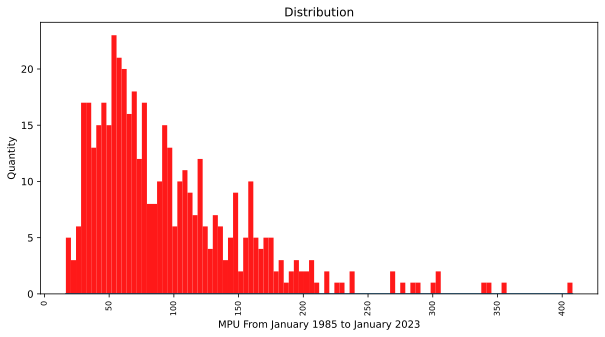

In [122]:
retmean = MPU['1985-01':'2023-01']['news'].mean()
retstd = MPU['1985-01':'2023-01']['news'].std()
retmin = MPU['1985-01':'2023-01']['news'].min()
retmax = MPU['1985-01':'2023-01']['news'].max()

def normfun(x, mu, sigma):
    pdf = np.exp(-((x - mu)**2) /
                 (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    return pdf


x = np.arange(retmin, retmax, 0.001)
y = normfun(x, retmean, retstd)
fig = plt.figure(figsize=(10, 5)) # 图片大小 10，5
plt.plot(x, y)

fig = plt.hist(MPU['1985-01':'2023-01']['news'],
               bins=100,
               histtype='bar',
               color='r',
               alpha=0.9)
plt.xticks(rotation=90, fontsize=8)
plt.title('Distribution')
plt.xlabel('MPU From January 1985 to January 2023')
plt.ylabel('Quantity')
plt.show();

In [125]:
from statsmodels.tsa.stattools import adfuller as ADF
print('原始序列的ADF检验结果为:', ADF(MPU['1985-01':'2023-01']['news']))

原始序列的ADF检验结果为: (-10.329655948906108, 2.8645572878478096e-18, 0, 456, {'1%': -3.4447721346720885, '5%': -2.8678991615065095, '10%': -2.570157193174823}, 4622.817345863891)


In [126]:
MPU['1985-01':'2023-01']['news'].mean()

94.93204945295406

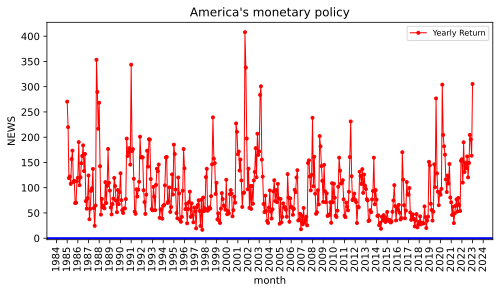

In [130]:
fig, ax = plt.subplots(figsize = (8,4))

ax.plot('news', # 图片数据
'.-', # 图片类型,
color = 'r', # 图片颜色
label = 'Yearly Return', # 图片标签
linewidth = 1, # 图片线宽
data = MPU['1985-01':]) # 图片数据来源
ax.set_title("America's monetary policy") # 图片标题
ax.set_ylabel('NEWS') # 图片y轴标签
ax.set_xlabel('month') # 图片x轴标签

# 添加一条y=0的参考线
plt.axhline(y=0, color='blue', linewidth=2)
# plt.axhline(y=0.005546421267857977, color='green', linewidth=2)

# 设置x轴的日期显示格式
data_format = mdates.DateFormatter('%Y')
ax.xaxis.set_major_formatter(data_format)
ax.xaxis.set_major_locator(mdates.YearLocator())

# 转置x轴的日期显示格式
plt.xticks(rotation = 90)

# 添加图例
plt.legend(loc='upper right',fontsize = 8)
plt.show();

In [131]:
MPU['1985-01':'2023-01']['news'].mean()

94.93204945295406

In [132]:
stats.ttest_1samp(MPU['1985-01':'2023-01']['news'],0)

TtestResult(statistic=33.92424540976945, pvalue=8.426693147491915e-127, df=456)

美国货币政策不确定性与美国股票收益率
经济政策的频繁变动会诱发投资者产生悲观情绪，而股票市场收益率又会因受到投资者负面情绪的影响而下降，最终导致不确定性对股票市场的冲击会部分通过投资者悲观情绪渠道传递。此外，不同类型经济政策不确定性对股市收益率影响存在差异性。【1】
【1】胡汪汪,罗添元.经济政策不确定性对股市收益率的影响——基于投资者情绪的中介效应检验[J].武汉金融,2022,(05):25-33.
已有研究表明货币政策的波动会影响股票收益率，因此我们选择货币政策不确定性指数进行计算
基准模型为：rt=α+βxt−1+ϵt
我选择了1985-2023年的数据进行分析


In [61]:
reg_data = pd.merge(US_market_ret, MPU, left_index=True, right_index=True)
reg_data = reg_data['1985':'2023']

reg_data

,r,Month,MPU,Unnamed: 3,Unnamed: 4,Unnamed: 5
1985-01-01,0.085719,1,270.4692,NaN,NaN,NaN
1985-02-01,0.016898,2,219.8357,NaN,NaN,NaN
1985-03-01,-0.001747,3,119.0345,NaN,NaN,NaN
1985-04-01,-0.002187,4,122.0448,NaN,NaN,NaN
1985-05-01,0.055774,5,107.5736,NaN,NaN,NaN
...,...,...,...,...,...,...
2022-09-01,-0.092081,9,149.0037,NaN,NaN,NaN
2022-10-01,0.078669,10,204.4937,NaN,NaN,NaN
2022-11-01,0.051431,11,195.6611,NaN,NaN,NaN
2022-12-01,-0.058719,12,163.2947,NaN,NaN,NaN


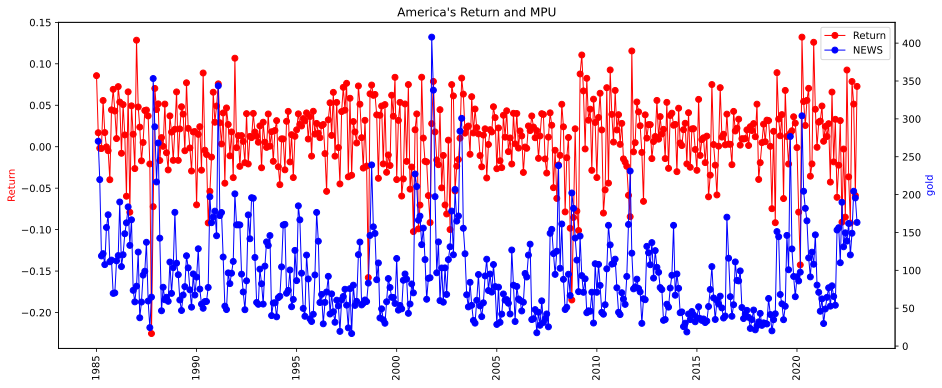

In [133]:
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(reg_data['r'], 
         label='Return', 
         color='red', 
         linewidth=1, 
         linestyle='-', 
         marker='o')
ax1.set_ylabel('Return',color='red')

data_format = mdates.DateFormatter('%Y')
ax1.xaxis.set_major_formatter(data_format)
ax1.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=90)

ax2 = ax1.twinx()
ax2.plot(reg_data['MPU'].shift(1), 
         label='NEWS', 
         color='blue', 
         linewidth=1, 
         linestyle='-', 
         marker='o')
ax2.set_ylabel('gold',color='blue')

plt.title("America's Return and MPU")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.show();

描述性统计

In [134]:
reg_data['r'].describe().round(3)

count    457.000
mean       0.010
std        0.045
min       -0.225
25%       -0.017
50%        0.015
75%        0.039
max        0.132
Name: r, dtype: float64

In [135]:
reg_data.skew().round(3)
reg_data.kurt().round(3)

r            -0.822
Month         0.002
MPU           1.633
Unnamed: 3      NaN
Unnamed: 4      NaN
Unnamed: 5      NaN
dtype: float64

r             2.377
Month        -1.219
MPU           3.759
Unnamed: 3      NaN
Unnamed: 4      NaN
Unnamed: 5      NaN
dtype: float64

yt=β0+β1xt+ξ，y为被解释变量，x为解释变量，ξ为扰动项 假设上式为该模型1

In [136]:
reg_data['lMPU'] = reg_data['MPU']/100
model_price = smf.ols('r ~ lMPU', data=reg_data).fit()
print(model_price.summary())

                            OLS Regression Results                            
Dep. Variable:                      r   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     8.728
Date:                Wed, 18 Dec 2024   Prob (F-statistic):            0.00330
Time:                        14:06:18   Log-Likelihood:                 769.31
No. Observations:                 457   AIC:                            -1535.
Df Residuals:                     455   BIC:                            -1526.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0195      0.004      4.932      0.0

由上述结果可知，回归结果p值小于5%，所以回归显著，美国货币政策不确定性可以预测美国股票市场收益率。
美国货币政策的不确定性对股票市场收益率的影响是通过多种渠道实现的，主要包括：利率的变化对企业估值的影响、市场波动性增加、对经济周期的影响、通胀预期的变化、投资者情绪的波动以及资本流动等因素。这些因素共同作用，导致股票市场在货币政策不确定性较高时面临较大的风险和波动，因此可能对股票市场收益率产生较大的负面影响。货币政策不确定性，尤其是关于利率变化、量化宽松（QE）、通货膨胀目标等政策的不确定性，会通过多个渠道影响股票市场的表现。

考虑道货币政策发布的时效性，进行滞后分析
yt=β0+β1xt-1+ξ

In [137]:
reg_data['llMPU'] = reg_data['MPU'].shift(1)/100
model_price = smf.ols('r ~ llMPU', data=reg_data).fit()
print(model_price.summary())

                            OLS Regression Results                            
Dep. Variable:                      r   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.688
Date:                Wed, 18 Dec 2024   Prob (F-statistic):             0.0554
Time:                        14:14:59   Log-Likelihood:                 766.05
No. Observations:                 456   AIC:                            -1528.
Df Residuals:                     454   BIC:                            -1520.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0029      0.004      0.737      0.4

结果显示，p值在5%，仍较显著，但p值相对于当期产生的回归结果大，结果没有当期的影响关系好，因此，货币政策不确定性对股票收益率不仅造成影响，而且会很快产生影响，因此，在预测股票收益率时，应尽可能选择当期的货币政策不确定性进行计分析。